# Optimización con Descenso de Gradiente y Adam (Regresión Lineal Múltiple)

**Objetivo docente (evaluable):** construir e interpretar un modelo de **regresión lineal múltiple** (3 variables) optimizando sus parámetros con:

- **Descenso de Gradiente (GD)**
- **Adam (Adaptive Moment Estimation)**

Al finalizar, podrás:
1. Implementar MSE y gradiente para regresión lineal.
2. Entrenar el mismo modelo con GD y Adam.
3. Comparar **convergencia**, **estabilidad**, **sensibilidad a la tasa de aprendizaje**.
4. Responder preguntas de interpretación (evaluación) y pasar **checks automáticos**.

> **Recomendación:** ejecuta el notebook de arriba hacia abajo (Kernel → Restart & Run All).

## 0. Setup y reproducibilidad

En este notebook:
- Generaremos datos sintéticos (controlados) para validar el aprendizaje.
- Usaremos solo `numpy`, `pandas` y `matplotlib`.

**Buenas prácticas:**
- Semilla fija (`np.random.seed`)
- Funciones puras para costo y gradientes
- Registros de métricas por iteración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Dataset sintético (3 variables explicativas)

Modelamos:

\[
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \varepsilon
\]

Ejemplo contextual (interpretación):
- \(x_1\): horas de estudio
- \(x_2\): asistencia a clases
- \(x_3\): experiencia previa
- \(y\): puntaje final

Construimos datos con coeficientes reales (ocultos para el modelo) y un ruido \(\varepsilon\).

In [2]:
# Parámetros del dataset
n = 300

# Features
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(0, 5, n)
X3 = np.random.uniform(0, 3, n)

# Coeficientes "reales" (ground truth)
B0_true = 5.0
B1_true = 2.0
B2_true = -1.5
B3_true = 3.0

# Ruido
eps = np.random.normal(0, 2.0, n)

# Variable objetivo
y = B0_true + B1_true*X1 + B2_true*X2 + B3_true*X3 + eps

df = pd.DataFrame({"X1": X1, "X2": X2, "X3": X3, "y": y})
df.head()

,X1,X2,X3,y
0,3.745401,0.258409,0.506805,14.275871
1,9.507143,2.656773,0.835771,20.034212
2,7.319939,2.703176,0.531031,19.026264
3,5.986585,3.187150,0.266108,12.620964
4,1.560186,3.630457,0.361908,2.714965


## 2. Exploración rápida

**Tarea (1 punto, formativa):** observa rangos y dispersión.

- ¿Cuál variable parece tener mayor impacto visual en `y`?
- ¿Se observa ruido?

> No buscamos conclusiones perfectas; solo lectura inicial.

In [3]:
df.describe()

,X1,X2,X3,y
count,300.000000,300.000000,300.000000,300.000000
mean,4.952046,2.554158,1.413267,15.462046
std,2.943405,1.512952,0.850282,7.118871
min,0.050616,0.054188,0.013896,-0.895999
25%,2.390808,1.248075,0.629300,10.430852
50%,5.117177,2.608514,1.358593,15.241336
75%,7.568596,3.866710,2.150965,20.650313
max,9.900539,4.998588,2.990623,34.514056


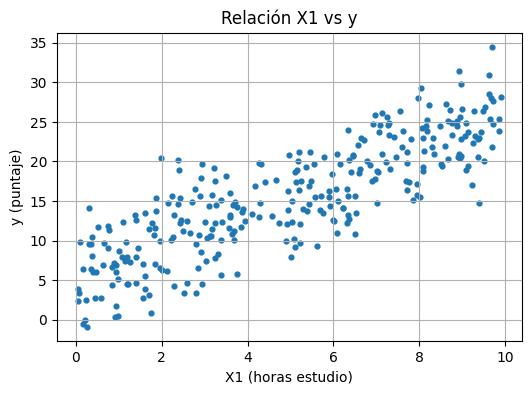

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(df["X1"], df["y"], s=12)
plt.xlabel("X1 (horas estudio)")
plt.ylabel("y (puntaje)")
plt.title("Relación X1 vs y")
plt.grid(True)
plt.show()

## 3. Preparación matricial + normalización

Para mejorar convergencia:
- Normalizamos features: \(X_{norm} = (X - \mu)/\sigma\)
- Agregamos columna de 1s para el intercepto (bias)

\[
\hat{y} = X_b \theta
\]

donde \(\theta = [\theta_0, \theta_1, \theta_2, \theta_3]^T\)

In [5]:
X = df[["X1", "X2", "X3"]].values
y_vec = df["y"].values.reshape(-1, 1)

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

X_b = np.c_[np.ones((n, 1)), X_norm]  # bias + features
X_b.shape, y_vec.shape

((300, 4), (300, 1))

## 4. Función de costo: MSE (y versión con 1/2m)

Usaremos la versión típica en aprendizaje:

\[
J(\theta)=\frac{1}{2m}\sum_{i=1}^{m}(y_i-\hat{y}_i)^2
\]

- El factor \(1/2\) **no cambia** el mínimo.
- Hace el gradiente más limpio.

**Tarea evaluable (2 puntos):**
- Implementa `compute_cost`.
- Debe devolver un número (float).

In [6]:
def compute_cost(X, y, theta):
    """Costo MSE escalado: J(theta) = (1/(2m)) * sum((X@theta - y)^2)."""
    m = len(y)
    preds = X @ theta
    err = preds - y
    return float((1/(2*m)) * np.sum(err**2))


# Smoke test rápido
theta0 = np.zeros((X_b.shape[1], 1))
compute_cost(X_b, y_vec, theta0)

144.79212651503008

## 5. Gradiente para regresión lineal

Para el costo anterior, el gradiente es:

\[
\nabla J(\theta)=\frac{1}{m}X^T(X\theta - y)
\]

**Tarea evaluable (2 puntos):**
- Implementa `compute_grad`.
- Debe devolver un vector columna con la misma forma de `theta`.

In [7]:
def compute_grad(X, y, theta):
    """Gradiente de J(theta): (1/m) X^T (X theta - y)."""
    m = len(y)
    return (1/m) * (X.T @ (X @ theta - y))


# Smoke test
g0 = compute_grad(X_b, y_vec, theta0)
g0.shape

(4, 1)

## 6. Descenso de Gradiente (GD)

Actualización:

\[
\theta \leftarrow \theta - \alpha \nabla J(\theta)
\]

**Indicadores a monitorear:**
- Costo decreciente
- Convergencia estable (sin explotar)

Incluiremos:
- historial de costo
- historial de norma del gradiente (opcional, útil)

In [8]:
def gradient_descent(X, y, alpha=0.05, epochs=1000, theta_init=None):
    m, n = X.shape
    theta = np.zeros((n, 1)) if theta_init is None else theta_init.copy()

    cost_hist = []
    grad_norm_hist = []

    for _ in range(epochs):
        grad = compute_grad(X, y, theta)
        theta = theta - alpha * grad

        cost_hist.append(compute_cost(X, y, theta))
        grad_norm_hist.append(float(np.linalg.norm(grad)))

    return theta, cost_hist, grad_norm_hist

## 7. Adam (Adaptive Moment Estimation)

Adam combina:
- **Momentum** (primer momento, promedio del gradiente)
- **RMSProp** (segundo momento, promedio del gradiente al cuadrado)

Actualización (por parámetro):

$$
m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t,\quad
v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2
$$

Con corrección de sesgo:

$$
\hat{m}_t=\frac{m_t}{1-\beta_1^t},\quad
\hat{v}_t=\frac{v_t}{1-\beta_2^t}
$$

y paso:

\[
\theta \leftarrow \theta-\alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
\]

Valores típicos:
- \(\beta_1=0.9\), \(\beta_2=0.999\), \(\epsilon=10^{-8}\)

**Tarea evaluable (3 puntos):**
- Revisa/entiende la implementación (ya provista).
- Ajusta `alpha` para observar estabilidad y rapidez.

In [9]:
def adam(X, y, alpha=0.01, epochs=1000, beta1=0.9, beta2=0.999, eps=1e-8, theta_init=None):
    m, n = X.shape
    theta = np.zeros((n, 1)) if theta_init is None else theta_init.copy()

    m_t = np.zeros_like(theta)
    v_t = np.zeros_like(theta)

    cost_hist = []
    grad_norm_hist = []

    for t in range(1, epochs + 1):
        g_t = compute_grad(X, y, theta)

        # momentos
        m_t = beta1 * m_t + (1 - beta1) * g_t
        v_t = beta2 * v_t + (1 - beta2) * (g_t ** 2)

        # corrección sesgo
        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)

        # update
        theta = theta - alpha * m_hat / (np.sqrt(v_hat) + eps)

        cost_hist.append(compute_cost(X, y, theta))
        grad_norm_hist.append(float(np.linalg.norm(g_t)))

    return theta, cost_hist, grad_norm_hist

## 8. Entrenamiento y comparación GD vs Adam

Entrenamos ambos optimizadores sobre el mismo problema y comparamos curvas.

> Nota: en Adam, un `alpha` típico es menor (p. ej. 0.01 o 0.001) que en GD clásico.

In [10]:
EPOCHS = 600

theta_gd, cost_gd, gradn_gd = gradient_descent(X_b, y_vec, alpha=0.05, epochs=EPOCHS)
theta_adam, cost_adam, gradn_adam = adam(X_b, y_vec, alpha=0.03, epochs=EPOCHS)

cost_gd[-1], cost_adam[-1]

(1.8287739917785326, 6.248144185651939)

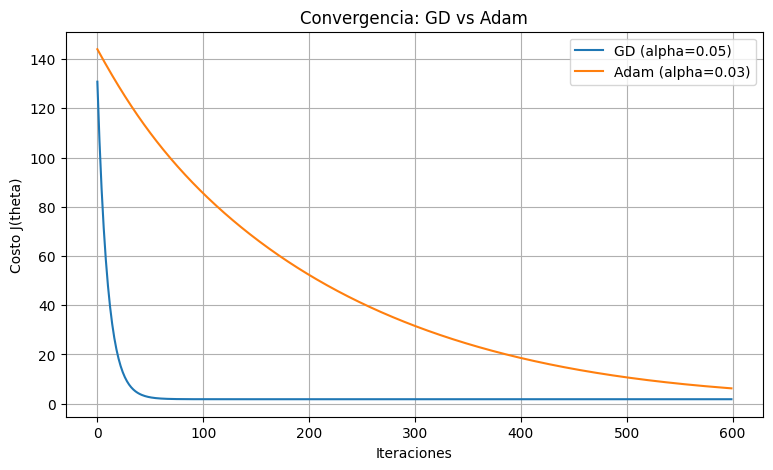

In [11]:
plt.figure(figsize=(9,5))
plt.plot(cost_gd, label="GD (alpha=0.05)")
plt.plot(cost_adam, label="Adam (alpha=0.03)")
plt.xlabel("Iteraciones")
plt.ylabel("Costo J(theta)")
plt.title("Convergencia: GD vs Adam")
plt.legend()
plt.grid(True)
plt.show()

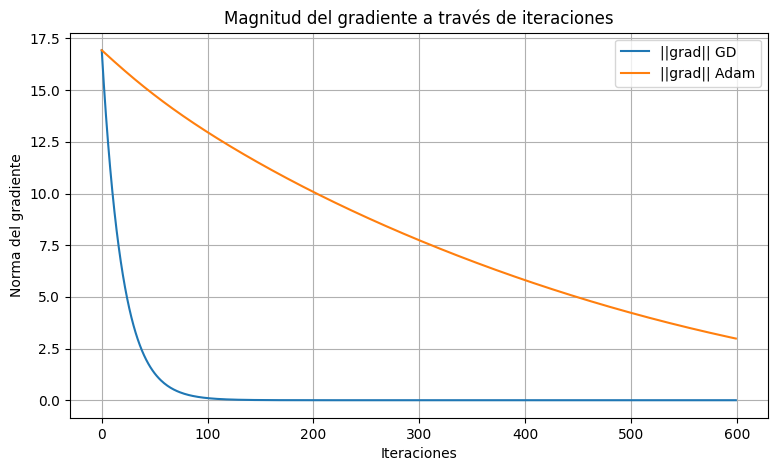

In [12]:
plt.figure(figsize=(9,5))
plt.plot(gradn_gd, label="||grad|| GD")
plt.plot(gradn_adam, label="||grad|| Adam")
plt.xlabel("Iteraciones")
plt.ylabel("Norma del gradiente")
plt.title("Magnitud del gradiente a través de iteraciones")
plt.legend()
plt.grid(True)
plt.show()

## 9. Recuperar coeficientes en escala original

Como entrenamos con features normalizados, los \(\theta\) estimados están en esa escala.
Convertimos a \(\beta\) en escala original:

Si:
\[
x_{norm}=\frac{x-\mu}{\sigma}
\]
entonces:
\[
\beta_j=\frac{\theta_j}{\sigma_j}
\]
y:
\[
\beta_0 = \theta_0 - \sum_{j=1}^{p}\frac{\mu_j}{\sigma_j}\theta_j
\]

**Tarea evaluable (2 puntos):**
- Comparar \(\beta\) estimados vs reales.
- Explicar en 2-3 líneas por qué no coinciden exactamente (pista: ruido).

In [13]:
def theta_to_beta(theta, X_mean, X_std):
    # theta: [theta0, theta1, theta2, theta3] en escala normalizada
    theta0 = float(theta[0])
    theta_rest = theta[1:].reshape(-1)

    beta_rest = theta_rest / X_std
    beta0 = theta0 - float(np.sum((X_mean / X_std) * theta_rest))
    return beta0, beta_rest

beta0_gd, betas_gd = theta_to_beta(theta_gd, X_mean, X_std)
beta0_adam, betas_adam = theta_to_beta(theta_adam, X_mean, X_std)

results = pd.DataFrame({
    "param": ["beta0", "beta1", "beta2", "beta3"],
    "true": [B0_true, B1_true, B2_true, B3_true],
    "GD": [beta0_gd, *betas_gd],
    "Adam": [beta0_adam, *betas_adam],
})
results

/var/folders/kh/ggpz15tx2nx71cnc0b_dy5jm0000gp/T/ipykernel_5166/2457866100.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta0 = float(theta[0])


,param,true,GD,Adam
0,beta0,5.0,4.906990,1.944015
1,beta1,2.0,1.992927,1.991221
2,beta2,-1.5,-1.476399,-1.476852
3,beta3,3.0,3.153649,3.153350


## 10. Predicción para nuevos casos

**Caso:** un nuevo estudiante con:
- \(x_1=6\), \(x_2=4\), \(x_3=2\)

Calcula predicción con Adam (y compárala con GD).

**Tarea evaluable (1 punto):**
- Implementa la función `predict`.

In [14]:
def predict(X_new, theta, X_mean, X_std):
    X_new = np.asarray(X_new, dtype=float)
    Xn = (X_new - X_mean) / X_std
    Xb = np.c_[np.ones((Xn.shape[0], 1)), Xn]
    return Xb @ theta

X_new = np.array([[6, 4, 2]])
yhat_gd = predict(X_new, theta_gd, X_mean, X_std)
yhat_adam = predict(X_new, theta_adam, X_mean, X_std)

yhat_gd, yhat_adam

(array([[17.26625089]]), array([[14.29063677]]))

## 11. Sección evaluable (rubrica + checks automáticos)

### Rubrica sugerida (10 puntos)

1. (2 pts) `compute_cost` correcto  
2. (2 pts) `compute_grad` correcto  
3. (2 pts) GD converge (costo baja y no diverge)  
4. (2 pts) Adam converge y suele llegar antes/igual que GD  
5. (2 pts) Interpretación: explica diferencias vs coeficientes reales + efectos de normalización

### Preguntas (responde en Markdown)
**P1.** ¿Qué observas en la curva de costo entre GD y Adam?  
**P2.** Si Adam fuera inestable (costo sube), ¿qué ajustarías primero y por qué?  
**P3.** ¿Por qué normalizar ayuda al descenso de gradiente?

> **Importante:** debajo hay celdas de validación con `assert`.  
> Si fallan, revisa tus funciones.

In [15]:
# === CHECKS AUTOMÁTICOS (no editar) ===

# 1) Tipos/salidas
theta_test = np.zeros((X_b.shape[1], 1))
c = compute_cost(X_b, y_vec, theta_test)
assert isinstance(c, float), "compute_cost debe devolver float."

g = compute_grad(X_b, y_vec, theta_test)
assert g.shape == theta_test.shape, "compute_grad debe devolver vector con misma forma que theta."

# 2) Gradiente: validación numérica rápida (diferencias finitas)
def approx_grad(X, y, theta, eps=1e-6):
    grad_approx = np.zeros_like(theta)
    for i in range(len(theta)):
        t1 = theta.copy(); t1[i,0] += eps
        t2 = theta.copy(); t2[i,0] -= eps
        grad_approx[i,0] = (compute_cost(X,y,t1) - compute_cost(X,y,t2)) / (2*eps)
    return grad_approx

ga = approx_grad(X_b, y_vec, theta_test)
max_diff = float(np.max(np.abs(ga - g)))
assert max_diff < 1e-3, f"Gradiente parece incorrecto. Diferencia máxima={max_diff:.2e}"

# 3) Convergencia básica
_, cost_gd_tmp, _ = gradient_descent(X_b, y_vec, alpha=0.05, epochs=200)
_, cost_adam_tmp, _ = adam(X_b, y_vec, alpha=0.03, epochs=200)

assert cost_gd_tmp[-1] < cost_gd_tmp[0], "GD no redujo el costo: revisa alpha/implementación."
assert cost_adam_tmp[-1] < cost_adam_tmp[0], "Adam no redujo el costo: revisa alpha/implementación."

print("✅ Checks OK: costo/gradiente/convergencia básica verificados.")

✅ Checks OK: costo/gradiente/convergencia básica verificados.


## 12. Extensiones opcionales (no evaluables)

1) Probar sensibilidad a `alpha`:
- GD: \(\alpha \in \{0.005, 0.01, 0.05, 0.1\}\)
- Adam: \(\alpha \in \{0.001, 0.003, 0.01, 0.03\}\)

2) Usar split train/test y reportar MSE en test.

3) Comparar con solución cerrada OLS (para validar coeficientes):
\[
\theta = (X^T X)^{-1}X^T y
\]